# Smart Temperature Prediction using IoT Data

This notebook demonstrates a machine learning pipeline for predicting temperature using IoT sensor data.

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import sys
%matplotlib inline
import warnings
import sqlite3
warnings.filterwarnings('ignore')

Load Data

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/iot_telemetry_data.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405184 entries, 0 to 405183
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   ts        405184 non-null  float64
 1   device    405184 non-null  object 
 2   co        405184 non-null  float64
 3   humidity  405184 non-null  float64
 4   light     405184 non-null  bool   
 5   lpg       405184 non-null  float64
 6   motion    405184 non-null  bool   
 7   smoke     405184 non-null  float64
 8   temp      405184 non-null  float64
dtypes: bool(2), float64(6), object(1)
memory usage: 22.4+ MB


In [ ]:
df.isna().sum()

ts          0
device      0
co          0
humidity    0
light       0
lpg         0
motion      0
smoke       0
temp        0
dtype: int64

In [ ]:
Data Preprocessing

In [ ]:
df = df.sort_values(by='ts', ascending=True)
df['temp'] = (df['temp'])

In [ ]:
# preview data
df.head(5)

,ts,device,co,humidity,light,lpg,motion,smoke,temp
0,1.594512e+09,b8:27:eb:bf:9d:51,0.004956,51.000000,False,0.007651,False,0.020411,22.700000
1,1.594512e+09,00:0f:00:70:91:0a,0.002840,76.000000,False,0.005114,False,0.013275,19.700001
2,1.594512e+09,b8:27:eb:bf:9d:51,0.004976,50.900000,False,0.007673,False,0.020475,22.600000
3,1.594512e+09,1c:bf:ce:15:ec:4d,0.004403,76.800003,True,0.007023,False,0.018628,27.000000
4,1.594512e+09,b8:27:eb:bf:9d:51,0.004967,50.900000,False,0.007664,False,0.020448,22.600000


In [ ]:
# filter temp/humidity, by device, for outliers (>1% & <99%)
df = df.loc[df['temp'] >df.groupby('device').temp.transform(lambda x: x.quantile(.01))]
df = df.loc[df['temp'] < df.groupby('device').temp.transform(lambda x: x.quantile(.99))]

df = df.loc[df['humidity'] > df.groupby('device').humidity.transform(lambda x: x.quantile(.01))]
df = df.loc[df['humidity'] < df.groupby('device').humidity.transform(lambda x: x.quantile(.99))]

In [ ]:
# group data by iot device
groups = df.groupby('device')

In [ ]:
df['ts'] = pd.to_datetime(df['ts'], unit='s')

In [ ]:
df.head(5)

,ts,device,co,humidity,light,lpg,motion,smoke,temp
0,2020-07-12 00:01:34.385974528,b8:27:eb:bf:9d:51,0.004956,51.000000,False,0.007651,False,0.020411,22.700000
1,2020-07-12 00:01:34.735567616,00:0f:00:70:91:0a,0.002840,76.000000,False,0.005114,False,0.013275,19.700001
2,2020-07-12 00:01:38.073572864,b8:27:eb:bf:9d:51,0.004976,50.900000,False,0.007673,False,0.020475,22.600000
3,2020-07-12 00:01:39.589145856,1c:bf:ce:15:ec:4d,0.004403,76.800003,True,0.007023,False,0.018628,27.000000
4,2020-07-12 00:01:41.761234944,b8:27:eb:bf:9d:51,0.004967,50.900000,False,0.007664,False,0.020448,22.600000


Exploratory Data Analysis

In [ ]:
conn = sqlite3.connect(':memory:')

df.to_sql('iot', conn, index=False)
cursor = conn.cursor()

query = """select device, AVG(temp) as average_temperature
    from iot group by device"""
cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)

('00:0f:00:70:91:0a', 19.36255246911829)
('1c:bf:ce:15:ec:4d', 26.025511285357403)
('b8:27:eb:bf:9d:51', 22.279969165276523)


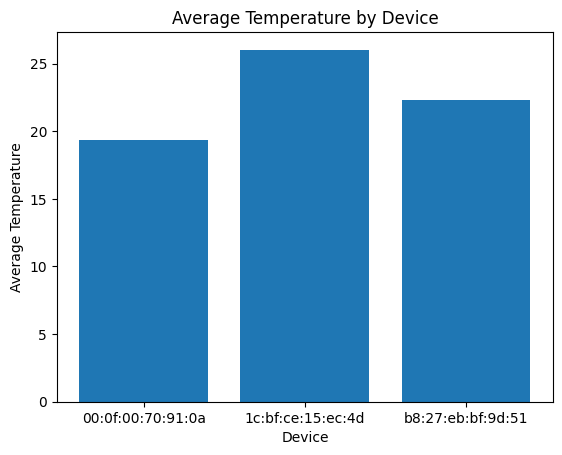

In [ ]:
result_df = pd.DataFrame(rows, columns=['Device', 'Average Temperature'])

plt.bar(result_df['Device'], result_df['Average Temperature'])
plt.xlabel('Device')
plt.ylabel('Average Temperature')
plt.title('Average Temperature by Device')
plt.show()


In [ ]:
import sys
print('DataFrame Stats')
print('-------------')
print('Record count: {:,}'.format(df['temp'].count()))
print('DataFrame size (MB): {:,.2f}'.format(sys.getsizeof(df)/1024/1024))
print('-------------')
print('Time range (min): {:%Y-%m-%d %H:%M:%S %Z}'.format(df.ts.iloc[1]))
print('Time range (max): {:%Y-%m-%d %H:%M:%S %Z}'.format(df.ts.iloc[-1]))
print('Temperature (min): {:.2f}'.format(df['temp'].min()))
print('Temperature (max): {:.2f}'.format(df['temp'].max()))
print('Humidity (min): {:.2f}{}'.format(df['humidity'].min(), '%'))
print('Humidity (max): {:.2f}{}'.format(df['humidity'].max(), '%'))
print('-------------')
print('Record count:\n{}'.format(groups.size()))

DataFrame Stats
-------------
Record count: 385,464
DataFrame size (MB): 48.52
-------------
Time range (min): 2020-07-12 00:01:34 
Time range (max): 2020-07-20 00:03:37 
Temperature (min): 18.70
Temperature (max): 30.20
Humidity (min): 46.60%
Humidity (max): 90.70%
-------------
Record count:
device
00:0f:00:70:91:0a    106187
1c:bf:ce:15:ec:4d    101056
b8:27:eb:bf:9d:51    178221
dtype: int64


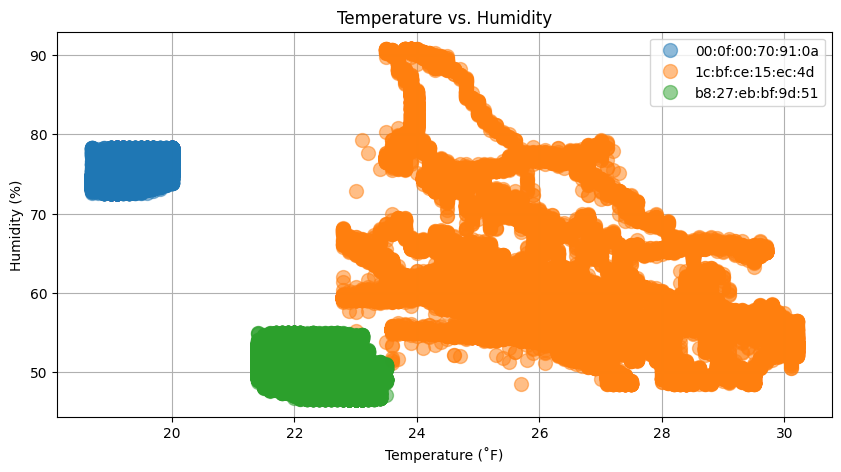

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(10, 5))
for device, group in groups:
    ax.plot(group.temp,
            group.humidity,
            marker='o',
            linestyle='',
            alpha=.5,
            ms=10,
            label=device)
ax.grid()
ax.margins(0.05)
ax.legend()
plt.title('Temperature vs. Humidity')
plt.xlabel('Temperature (˚F)')
plt.ylabel('Humidity (%)')
plt.show()

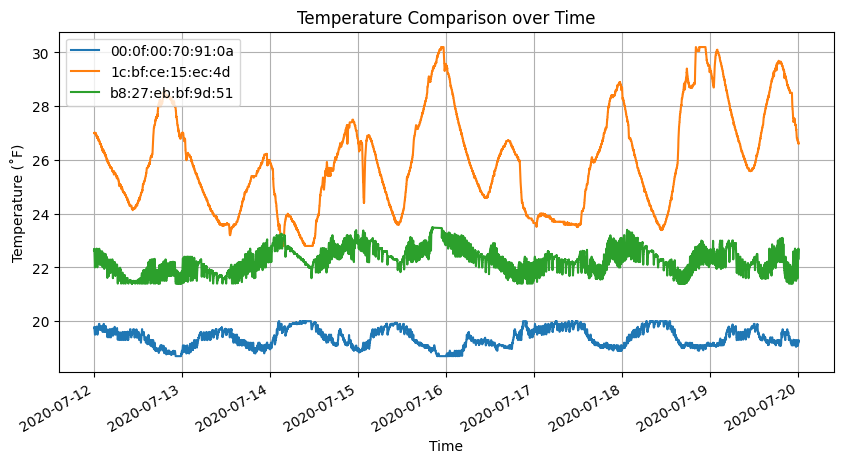

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for device, group in groups:
    group_mean = group.temp.rolling(window=20).mean()
    ax.plot(group.ts, group_mean, label=device)

fig.autofmt_xdate()
ax.grid()
ax.margins(0.05)
ax.legend()
plt.title('Temperature Comparison over Time')
plt.ylabel('Temperature (˚F)')
plt.xlabel('Time')
plt.show()

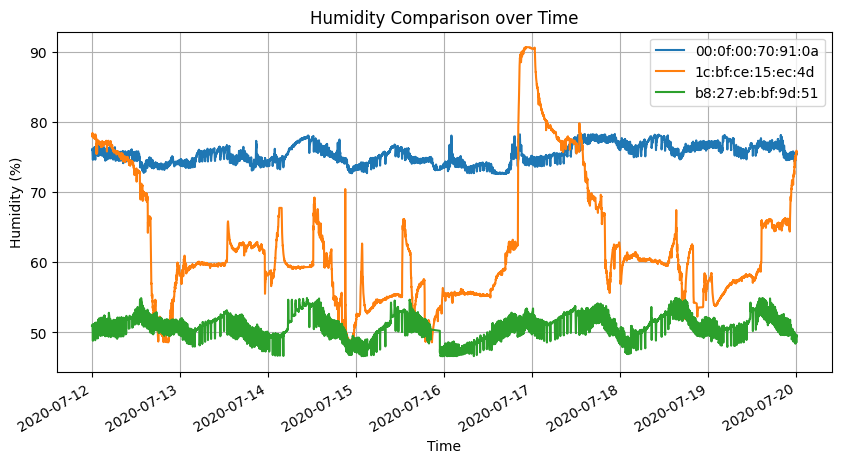

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for device, group in groups:
    group.mean = group.humidity.rolling(window=20).mean()
    ax.plot(group.ts,group.mean,
            label=device)
fig.autofmt_xdate()
ax.grid()
ax.margins(0.05)
ax.legend()
plt.title('Humidity Comparison over Time')
plt.ylabel('Humidity (%)')
plt.xlabel('Time')
plt.show()

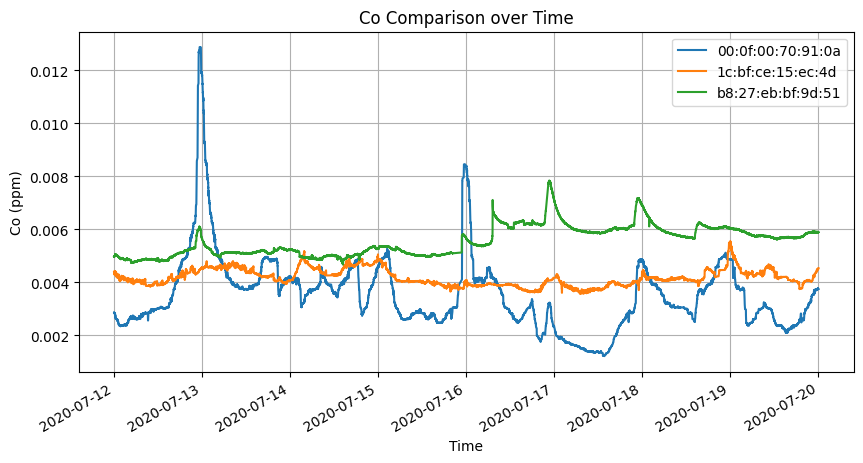

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for device, group in groups:
    group.mean = group.co.rolling(window=20).mean()
    ax.plot(group.ts,group.mean,
            label=device)
fig.autofmt_xdate()
ax.grid()
ax.margins(0.05)
ax.legend()
plt.title('Co Comparison over Time')
plt.ylabel('Co (ppm)')
plt.xlabel('Time')
plt.show()

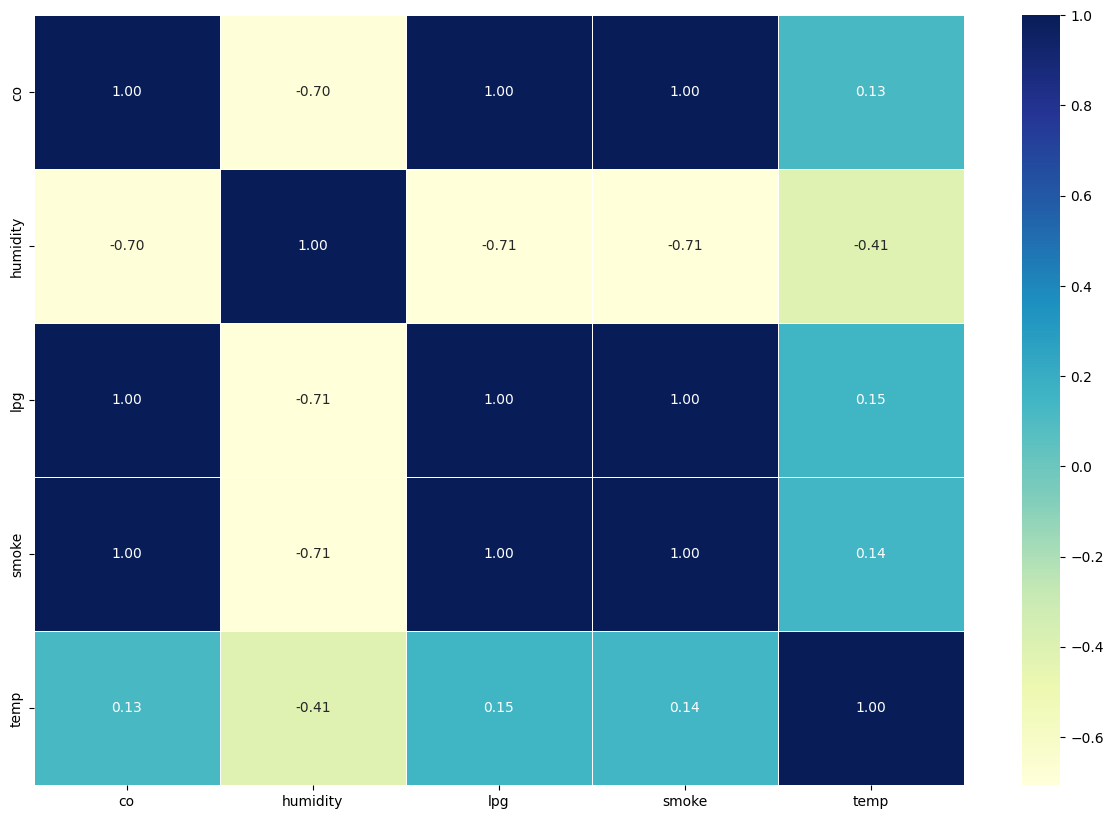

In [ ]:
import seaborn as sn
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix for numeric columns
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(15, 10))
sn.heatmap(corr_matrix, annot=True, linewidths=0.5, fmt=".2f", cmap="YlGnBu")
plt.show()

In [ ]:
df['date'] = df['ts'].dt.date.astype(str)
df['time'] = df['ts'].dt.strftime("%H:%M:%S %Z")

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ts,385464,2020-07-16 00:14:54.340532224,2020-07-12 00:01:34.385974528,2020-07-13 23:46:01.219121152,2020-07-16 00:32:18.637849088,2020-07-18 00:32:08.077775360,2020-07-20 00:03:37.264312576,NaN
co,385464.0,0.004629,0.001181,0.003919,0.004797,0.005412,0.01318,0.001216
humidity,385464.0,60.521308,46.6,51.1,54.9,74.400002,90.699997,11.206889
lpg,385464.0,0.007228,0.002711,0.006456,0.007472,0.008154,0.015524,0.001413
smoke,385464.0,0.019237,0.006738,0.017024,0.019902,0.021849,0.043461,0.003995
temp,385464.0,22.46785,18.700001,19.9,22.2,23.6,30.200001,2.641988


Train GradientBoostingRegressor and Evaluation

Mean Squared Error: 0.4784449996793249
R-squared: 0.9343085658808437


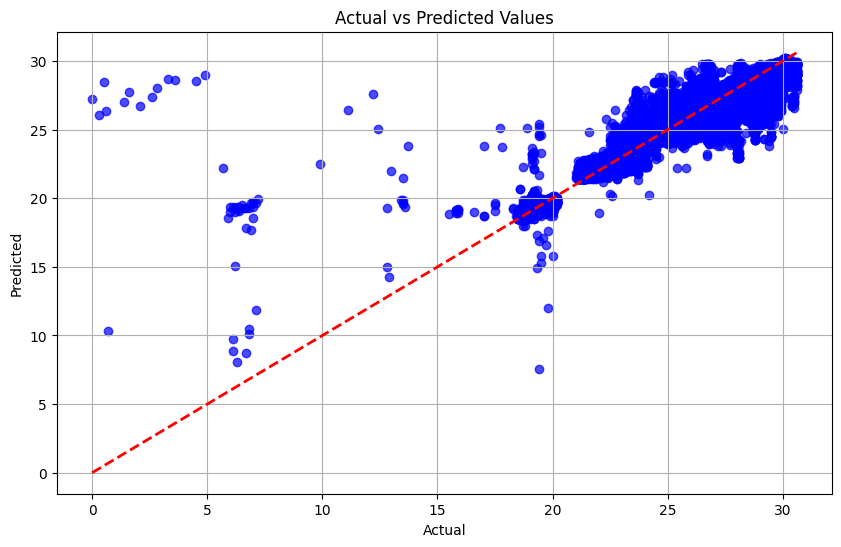

Predicted Temperature: 24.746858596801758


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib
import numpy as np
data = pd.read_csv('/content/drive/MyDrive/iot_telemetry_data.csv')

data['light'] = data['light'].astype(int)
data['motion'] = data['motion'].astype(int)


X = data[['co', 'humidity', 'light', 'lpg', 'motion', 'smoke']]
y = data['temp']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train)


joblib.dump(model, 'xgboost_regression_model.joblib')
joblib.dump(scaler, 'scaler.joblib')


y_pred = model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')


plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='b')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Values')
plt.show()


def predict_temperature(user_input):
    # Load the trained model
    model = joblib.load('xgboost_regression_model.joblib')
    scaler = joblib.load('scaler.joblib')


    user_input = np.array(user_input).reshape(1, -1)
    user_input_scaled = scaler.transform(user_input)


    predicted_temp = model.predict(user_input_scaled)
    return predicted_temp[0]


user_input = [0.004, 55.0, 1, 0.006, 0, 0.018]

predicted_temp = predict_temperature(user_input)
print(f'Predicted Temperature: {predicted_temp}')


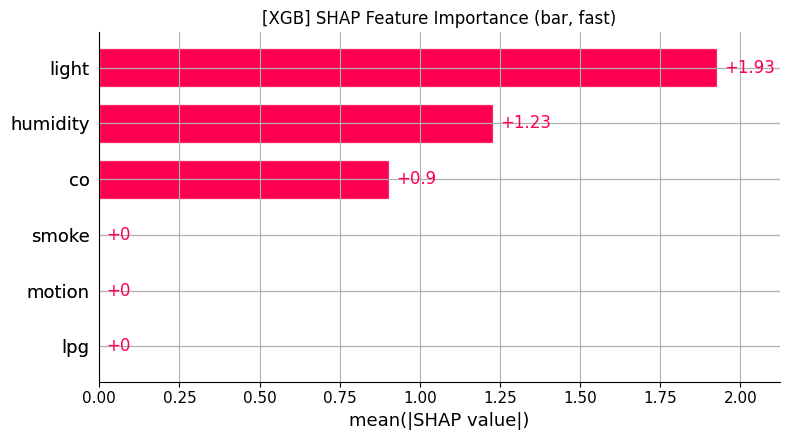

Saved: xgb_shap_bar_fast.png


In [ ]:
import shap, joblib, matplotlib.pyplot as plt

CSV_PATH = '/content/drive/MyDrive/iot_telemetry_data.csv'
FEATURES = ['co','humidity','light','lpg','motion','smoke']
TARGET   = 'temp'
MODEL_P  = 'xgboost_regression_model.joblib'
SCALER_P = 'scaler.joblib'
N_BG, N_PLOT = 100, 200

df = pd.read_csv(CSV_PATH)
for c in ["light","motion"]:
    if c in df.columns: df[c] = df[c].astype(int)

X_raw = df[FEATURES].copy()
y     = df[TARGET].copy()
Xtr_raw, Xte_raw, ytr, yte = train_test_split(X_raw, y, test_size=0.2, random_state=42)

scaler = joblib.load(SCALER_P)
model  = joblib.load(MODEL_P)

Xtr_s = pd.DataFrame(scaler.transform(Xtr_raw), columns=FEATURES, index=Xtr_raw.index)
Xte_s = pd.DataFrame(scaler.transform(Xte_raw), columns=FEATURES, index=Xte_raw.index)

bg_df   = Xtr_s.sample(min(N_BG, len(Xtr_s)), random_state=42)
X_plot  = Xte_s.sample(min(N_PLOT, len(Xte_s)), random_state=42)


explainer = None
try:
    masker = shap.maskers.Independent(bg_df)
    explainer = shap.Explainer(model, masker)
except Exception:

    explainer = shap.TreeExplainer(model)

sv_obj = explainer(X_plot, check_additivity=False)


plt.figure(figsize=(8,5))
try:
    shap.plots.bar(sv_obj, show=False, max_display=len(FEATURES))
except Exception:
    vals = getattr(sv_obj, "values", sv_obj)
    shap.summary_plot(vals, X_plot, feature_names=FEATURES,
                      plot_type="bar", show=False)
plt.title("[XGB] SHAP Feature Importance (bar, fast)")
plt.tight_layout()
plt.savefig("xgb_shap_bar_fast.png", dpi=300)
plt.show()

print("Saved: xgb_shap_bar_fast.png")


Model Comparison

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
import joblib
import numpy as np

X = data[['co', 'humidity', 'light', 'lpg', 'motion', 'smoke']]
y = data['temp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regression': DecisionTreeRegressor(random_state=42),
    'KNN Regression': KNeighborsRegressor(n_neighbors=5),
    'Random Forest Regression': RandomForestRegressor(random_state=42),
    'XGBoost Regression': XGBRegressor(objective='reg:squarederror', random_state=42)
}

r2_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r2_scores[name] = r2
    print(f'{name} - R-squared: {r2}')

print("\nR-squared values:")
for name, r2 in r2_scores.items():
    print(f'{name}: {r2}')


Linear Regression - R-squared: 0.781202040088619
Decision Tree Regression - R-squared: 0.9252547877901746
KNN Regression - R-squared: 0.9291567059973884
Random Forest Regression - R-squared: 0.9326115749201046
XGBoost Regression - R-squared: 0.9343085658808437

R-squared values:
Linear Regression: 0.781202040088619
Decision Tree Regression: 0.9252547877901746
KNN Regression: 0.9291567059973884
Random Forest Regression: 0.9326115749201046
XGBoost Regression: 0.9343085658808437


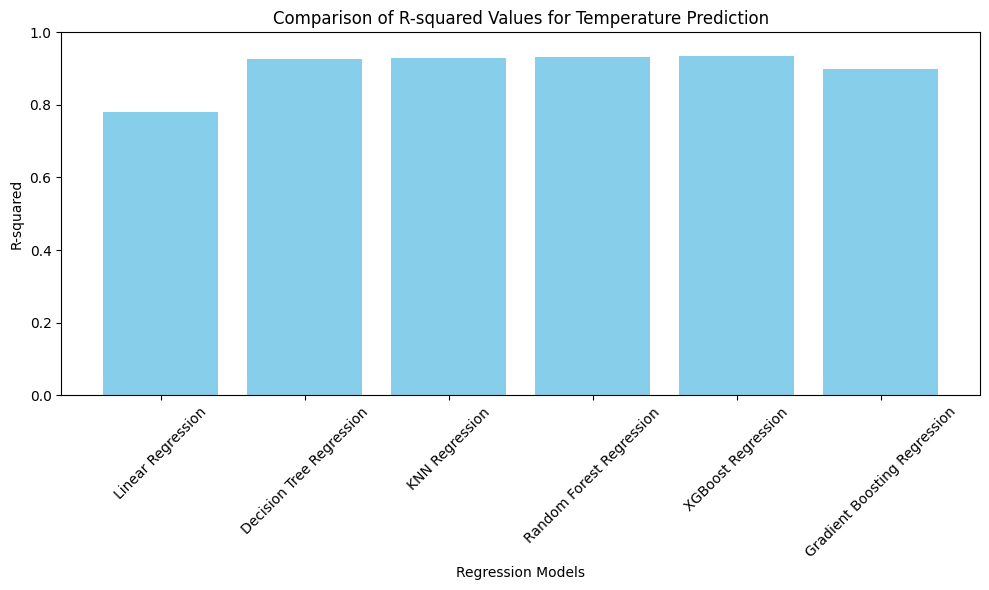


R-squared values:
Linear Regression: 0.781202040088619
Decision Tree Regression: 0.9252547877901746
KNN Regression: 0.9291567059973884
Random Forest Regression: 0.9326115749201046
XGBoost Regression: 0.9343085658808437
Gradient Boosting Regression: 0.8992023989744927


In [ ]:
# Plotting results
plt.figure(figsize=(10, 6))
plt.bar(r2_scores.keys(), r2_scores.values(), color='skyblue')
plt.xlabel('Regression Models')
plt.ylabel('R-squared')
plt.title('Comparison of R-squared Values for Temperature Prediction')
plt.ylim(0, 1)  # Adjust y-axis limits if necessary
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Compare R-squared values
print("\nR-squared values:")
for name, r2 in r2_scores.items():
    print(f'{name}: {r2}')

In [ ]:
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

df_predictions = pd.DataFrame(predictions)
correlation_matrix = df_predictions.corr()

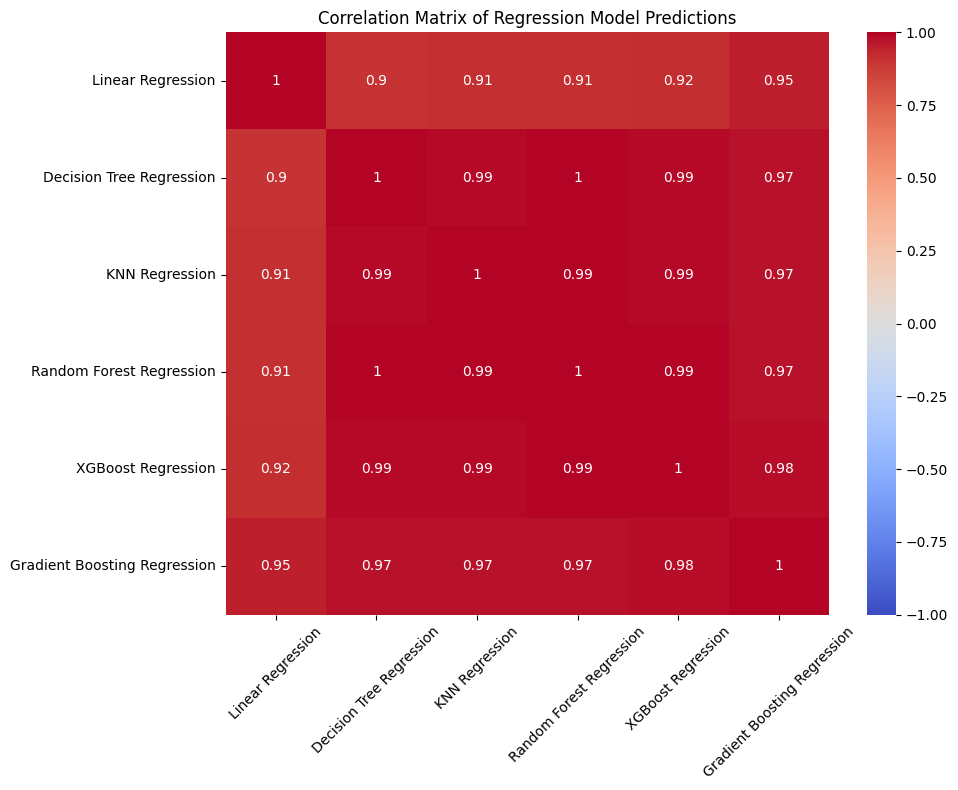

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Regression Model Predictions')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "k-NN": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}


results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    n_runs = 100
    start = time.time()
    for _ in range(n_runs):
        model.predict(X_test)
    end = time.time()

    avg_time = (end - start) / n_runs
    per_sample_ms = (avg_time / len(X_test)) * 1000

    results.append([name, r2, rmse, mae, per_sample_ms])


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "R² Score",
        "RMSE",
        "MAE",
        "Inference Time (ms/sample)"
    ]
).sort_values(by="R² Score", ascending=False)

print(results_df)


               Model  R² Score      RMSE       MAE  Inference Time (ms/sample)
3      Random Forest  0.932589  0.700690  0.305584                    0.055237
2               k-NN  0.929157  0.718309  0.315266                    0.109401
1      Decision Tree  0.925409  0.737061  0.313514                    0.001195
5            XGBoost  0.918881  0.768638  0.420455                    0.005052
4  Gradient Boosting  0.899085  0.857314  0.490925                    0.001903
0  Linear Regression  0.781202  1.262360  0.727017                    0.000045


In [ ]:
def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, alpha=0.05):
    rng = np.random.default_rng(42)
    scores = []

    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        scores.append(metric_fn(y_true[idx], y_pred[idx]))

    lower = np.percentile(scores, 100 * alpha / 2)
    upper = np.percentile(scores, 100 * (1 - alpha / 2))
    return np.mean(scores), lower, upper


# example for R²
mean_r2, r2_low, r2_high = bootstrap_ci(
    y_test.values,
    preds,
    r2_score
)

# example for RMSE
rmse_fn = lambda yt, yp: np.sqrt(mean_squared_error(yt, yp))
mean_rmse, rmse_low, rmse_high = bootstrap_ci(
    y_test.values,
    preds,
    rmse_fn
)

print(f"R² = {mean_r2:.3f} (95% CI: {r2_low:.3f}–{r2_high:.3f})")
print(f"RMSE = {mean_rmse:.3f} (95% CI: {rmse_low:.3f}–{rmse_high:.3f})")


R² = 0.919 (95% CI: 0.911–0.927)
RMSE = 0.768 (95% CI: 0.728–0.809)


## Conclusion
The model demonstrates strong performance in predicting temperature using IoT sensor data.